# 14 Chi-Square Test

Chapter 13 used t-tests to investigate **quantitative means**.

Now we move to **categorical data**.

The chi-square family answers questions such as:

> **Does an observed categorical distribution match an expected distribution?**

and:

> **Are two categorical variables associated?**

This chapter covers:

1. Chi-Square Goodness-of-Fit Test
2. Chi-Square Test of Independence

## Learning Objectives

After completing this chapter, you will be able to:

- distinguish observed and expected frequencies;
- understand the chi-square statistic;
- perform a goodness-of-fit test;
- build and interpret a contingency table;
- perform a chi-square test of independence;
- calculate expected cell counts;
- understand degrees of freedom;
- interpret p-values correctly;
- examine standardized residuals;
- calculate Cramér's V as an effect-size measure;
- recognize important assumptions and limitations.

## 1. From Means to Counts

A t-test works with quantitative measurements and means.

A chi-square test usually works with **counts in categories**.

For example:

| Plan | Count |
|---|---:|
| Basic | 110 |
| Standard | 115 |
| Premium | 75 |

The central comparison is between:

- **Observed frequencies**: what the data actually contain;
- **Expected frequencies**: what we would expect under $H_0$.

## 2. The Chi-Square Statistic

The general statistic is:

$$
\chi^2=
\sum\frac{(O-E)^2}{E}
$$

where:

- $O$ = observed frequency;
- $E$ = expected frequency.

If observed counts are close to expected counts, $\chi^2$ is relatively small.

If they differ substantially, $\chi^2$ becomes larger.

Because differences are squared, the statistic is nonnegative:

$$
\chi^2\geq0
$$

## 3. Dataset

`14_chi_square_test.csv` contains 300 fictional customers.

Columns:

- `customer_id`
- `plan`: Basic / Standard / Premium
- `satisfaction`: Low / Medium / High
- `signup_channel`: Web / Store / Phone

The dataset is synthetic and exists only for statistical education.

The data were generated so that plan and satisfaction have some association, giving us a useful independence-test example.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

cwd=Path.cwd().resolve()
root=next((p for p in [cwd,*cwd.parents] if (p/"data").is_dir()),None)
if root is None:
    raise FileNotFoundError("Could not find project root containing data/.")

df=pd.read_csv(root/"data"/"14_chi_square_test.csv")
df.head()

,customer_id,plan,satisfaction,signup_channel
0,Customer_001,Premium,High,Web
1,Customer_002,Standard,Low,Store
2,Customer_003,Premium,High,Phone
3,Customer_004,Standard,Medium,Store
4,Customer_005,Basic,High,Phone


In [2]:
print(f"Rows: {len(df)}")
print("\nPlan counts:")
print(df["plan"].value_counts())
print("\nSatisfaction counts:")
print(df["satisfaction"].value_counts())

Rows: 300

Plan counts:
plan
Basic       119
Standard    106
Premium      75
Name: count, dtype: int64

Satisfaction counts:
satisfaction
Medium    119
High       97
Low        84
Name: count, dtype: int64


# Part A — Chi-Square Goodness-of-Fit Test

## 4. Research Question

Suppose a fictional business expects its customer plans to follow:

$$
Basic:40\%,\quad Standard:35\%,\quad Premium:25\%
$$

We ask:

> **Does the observed plan distribution differ from this expected distribution?**

The hypotheses are:

$$
H_0:\text{The population proportions follow }(0.40,0.35,0.25)
$$

$$
H_1:\text{The population distribution differs from those proportions}
$$

## 5. Observed Frequencies

In [3]:
plan_order=["Basic","Standard","Premium"]
observed=df["plan"].value_counts().reindex(plan_order)
observed

plan
Basic       119
Standard    106
Premium      75
Name: count, dtype: int64

## 6. Expected Frequencies

With $N=300$:

$$
E_i=Np_i
$$

For example, if Basic is expected to be 40%:

$$
E_{Basic}=300\times0.40=120
$$

In [4]:
expected_proportions=np.array([0.40,0.35,0.25])
expected=len(df)*expected_proportions

gof_table=pd.DataFrame({
    "Observed":observed.values,
    "Expected":expected,
},index=plan_order)

gof_table

,Observed,Expected
Basic,119,120.0
Standard,106,105.0
Premium,75,75.0


## 7. Calculate $\chi^2$ Manually

For each category:

$$
\frac{(O-E)^2}{E}
$$

Then sum all contributions.

In [5]:
gof_table["Contribution"]=(gof_table["Observed"]-gof_table["Expected"])**2/gof_table["Expected"]
gof_table

,Observed,Expected,Contribution
Basic,119,120.0,0.008333
Standard,106,105.0,0.009524
Premium,75,75.0,0.000000


In [6]:
chi2_manual=gof_table["Contribution"].sum()
print(f"Manual chi-square = {chi2_manual:.4f}")

Manual chi-square = 0.0179


## 8. Goodness-of-Fit Test with SciPy

For $k$ categories with no parameters estimated from the same data in this simple setup:

$$
df=k-1
$$

In [7]:
gof_result=stats.chisquare(
    f_obs=observed.values,
    f_exp=expected,
)

print(f"chi-square = {gof_result.statistic:.4f}")
print(f"p-value    = {gof_result.pvalue:.6f}")
print(f"df         = {len(plan_order)-1}")

chi-square = 0.0179
p-value    = 0.991111
df         = 2


## 9. Interpretation

Using:

$$
\alpha=0.05
$$

- if $p<0.05$, reject $H_0$;
- otherwise, fail to reject $H_0$.

A rejection means the observed distribution provides evidence against the specified expected population proportions.

It does **not** tell us merely that some observed counts are numerically different—sampling variation makes some difference inevitable.

# Part B — Chi-Square Test of Independence

## 10. Research Question

Now consider two categorical variables:

- `plan`
- `satisfaction`

We ask:

> **Is satisfaction associated with plan?**

The hypotheses are:

$$
H_0:\text{Plan and satisfaction are independent}
$$

$$
H_1:\text{Plan and satisfaction are associated}
$$

## 11. Contingency Table

In [8]:
table=pd.crosstab(df["plan"],df["satisfaction"])
table=table.reindex(index=["Basic","Standard","Premium"],columns=["Low","Medium","High"])
table

satisfaction,Low,Medium,High
plan,,,
Basic,47,49,23
Standard,26,44,36
Premium,11,26,38


## 12. Visualize the Observed Counts

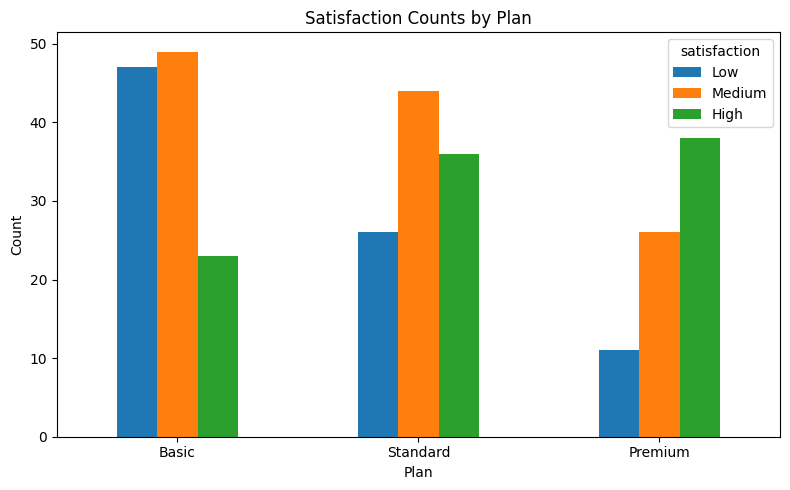

In [9]:
table.plot(kind="bar",figsize=(8,5))
plt.title("Satisfaction Counts by Plan")
plt.xlabel("Plan")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Expected Frequencies Under Independence

If the variables are independent, the expected count for cell $(i,j)$ is:

$$
E_{ij}
=
\frac{(\text{Row Total}_i)(\text{Column Total}_j)}
{\text{Grand Total}}
$$

This gives the counts we would expect if plan and satisfaction had no association.

In [10]:
row_totals=table.sum(axis=1)
column_totals=table.sum(axis=0)
grand_total=table.to_numpy().sum()

expected_manual=np.outer(row_totals,column_totals)/grand_total
expected_df=pd.DataFrame(
    expected_manual,
    index=table.index,
    columns=table.columns,
)
expected_df.round(2)

satisfaction,Low,Medium,High
plan,,,
Basic,33.32,47.20,38.48
Standard,29.68,42.05,34.27
Premium,21.00,29.75,24.25


## 14. Chi-Square Test of Independence with SciPy

For an $r\times c$ contingency table:

$$
df=(r-1)(c-1)
$$

In [11]:
chi2,p_value,dof,expected_scipy=stats.chi2_contingency(table)

print(f"chi-square = {chi2:.4f}")
print(f"p-value    = {p_value:.6f}")
print(f"df         = {dof}")

chi-square = 25.5752
p-value    = 0.000039
df         = 4


## 15. Confirm the Expected Counts

In [12]:
pd.DataFrame(
    expected_scipy,
    index=table.index,
    columns=table.columns,
).round(2)

satisfaction,Low,Medium,High
plan,,,
Basic,33.32,47.20,38.48
Standard,29.68,42.05,34.27
Premium,21.00,29.75,24.25


## 16. Which Cells Drive the Association?

A significant overall chi-square result tells us that some association exists, but not automatically **where** the largest departures occur.

A useful exploratory diagnostic is the Pearson residual:

$$
R_{ij}=
\frac{O_{ij}-E_{ij}}{\sqrt{E_{ij}}}
$$

- positive residual: observed count is above expectation;
- negative residual: observed count is below expectation;
- larger absolute residual: stronger contribution to the discrepancy.

Residuals should be interpreted as follow-up diagnostics rather than as a substitute for the overall test.

In [13]:
residuals=(table-expected_scipy)/np.sqrt(expected_scipy)
residuals.round(2)

satisfaction,Low,Medium,High
plan,,,
Basic,2.37,0.26,-2.50
Standard,-0.68,0.30,0.29
Premium,-2.18,-0.69,2.79


## 17. Visualize Residuals

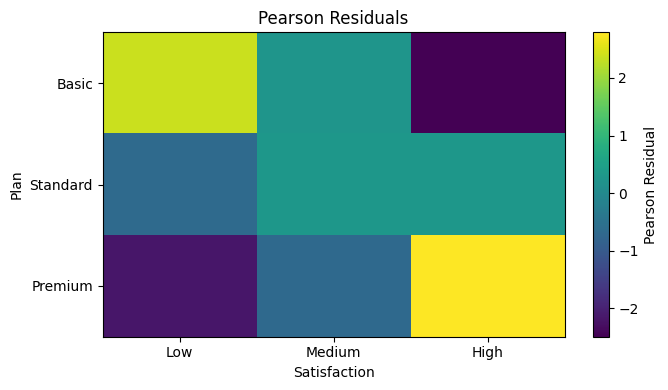

In [14]:
plt.figure(figsize=(7,4))
plt.imshow(residuals.values,aspect="auto")
plt.colorbar(label="Pearson Residual")
plt.xticks(range(len(residuals.columns)),residuals.columns)
plt.yticks(range(len(residuals.index)),residuals.index)
plt.title("Pearson Residuals")
plt.xlabel("Satisfaction")
plt.ylabel("Plan")
plt.tight_layout()
plt.show()

## 18. Effect Size — Cramér's V

A p-value addresses evidence against independence, but it does not directly describe the **strength** of association.

For an $r\times c$ table, Cramér's V is:

$$
V=
\sqrt{
\frac{\chi^2}
{N\min(r-1,c-1)}
}
$$

Its range is:

$$
0\leq V\leq1
$$

Values closer to zero indicate weaker association; larger values indicate stronger association.

Context matters when judging practical importance.

In [15]:
r,c=table.shape
cramers_v=np.sqrt(
    chi2/(grand_total*min(r-1,c-1))
)
print(f"Cramér's V = {cramers_v:.3f}")

Cramér's V = 0.206


# Part C — Assumptions and Interpretation

## 19. Expected Cell Counts Matter

The chi-square approximation works best when expected cell counts are not too small.

A commonly taught rule of thumb is that expected counts should generally be around 5 or larger, though more nuanced guidelines exist.

Let's inspect our table.

In [16]:
expected_check=pd.DataFrame(
    expected_scipy,
    index=table.index,
    columns=table.columns,
)
print(f"Minimum expected count: {expected_check.min().min():.2f}")
print(f"Cells below 5: {(expected_check < 5).sum().sum()}")

Minimum expected count: 21.00
Cells below 5: 0


## 20. Other Important Assumptions

For the usual chi-square procedures:

- data should be **counts**, not percentages alone;
- categories should be mutually exclusive for each variable;
- observations should be sufficiently independent;
- expected frequencies should be adequate for the approximation;
- the sampling/data-collection design must support the intended inference.

A small p-value cannot repair biased or dependent data.

## 21. Association Does Not Mean Causation

If we reject independence, we have evidence that the variables are associated.

That does **not** establish:

$$
\text{Plan}\rightarrow\text{Satisfaction}
$$

as a causal relationship.

Other variables or selection mechanisms may explain part or all of the association.

> **Chi-square tests association, not causation.**

## 22. Goodness-of-Fit vs Independence

### Goodness-of-Fit

One categorical variable is compared with a specified theoretical distribution.

Example:

$$
Observed\ Plan\ Distribution
\quad vs\quad
40\%/35\%/25\%
$$

### Independence

Two categorical variables are compared.

Example:

$$
Plan
\quad vs\quad
Satisfaction
$$

The same chi-square idea appears in both, but the research questions are different.

## 23. Connection to Earlier Chapters

The logic is still the Chapter 12 hypothesis-testing framework:

$$
H_0/H_1
\rightarrow
\text{Test Statistic}
\rightarrow
p\text{-value}
\rightarrow
\text{Decision}
\rightarrow
\text{Interpretation}
$$

What changes is the type of data.

### Chapter 13

$$
\text{Quantitative Data}\rightarrow\text{Means}\rightarrow t
$$

### Chapter 14

$$
\text{Categorical Data}\rightarrow\text{Counts}\rightarrow\chi^2
$$

## Important Distinctions

### Observed vs Expected Frequency
Observed frequencies come from the data. Expected frequencies come from the null model.

### Goodness-of-Fit vs Independence
Goodness-of-fit concerns one categorical variable and a specified distribution. Independence concerns the relationship between two categorical variables.

### Statistical Significance vs Association Strength
A p-value evaluates evidence against $H_0$. Cramér's V describes association strength.

### Association vs Causation
A significant chi-square test does not establish causality.

### Counts vs Percentages
The chi-square calculation is based on frequencies/counts. Percentages can help interpretation but do not replace the underlying counts.

## Exercises

### Exercise 1
Change the expected plan proportions to:

$$
(0.33,0.33,0.34)
$$

and repeat the goodness-of-fit test.

### Exercise 2
Manually calculate each goodness-of-fit contribution:

$$
\frac{(O-E)^2}{E}
$$

and confirm the SciPy result.

### Exercise 3
Create a contingency table between `signup_channel` and `satisfaction`.

Run a chi-square test of independence.

### Exercise 4
For the plan × satisfaction table, identify the cells with the largest positive and negative Pearson residuals.

### Exercise 5
Calculate Cramér's V for `signup_channel` × `satisfaction`.

### Exercise 6
Explain why a significant chi-square result does not prove that plan causes satisfaction.

### Exercise 7
For each scenario, choose goodness-of-fit or independence:

1. Whether four product colors occur in expected proportions.
2. Whether device type is related to subscription category.
3. Whether survey responses match a claimed 50/30/20 distribution.

### Exercise 8
Explain why very small expected cell counts can make the usual chi-square approximation questionable.

## Summary

Chi-square tests extend hypothesis testing to categorical frequencies.

### Goodness-of-Fit

$$
\text{Observed Distribution}
\rightarrow
\text{Expected Distribution}
\rightarrow
\chi^2
$$

### Independence

$$
\text{Contingency Table}
\rightarrow
\text{Expected Counts Under Independence}
\rightarrow
\chi^2
$$

The central statistic is:

$$
\chi^2=\sum\frac{(O-E)^2}{E}
$$

You learned:

- observed and expected frequencies;
- goodness-of-fit testing;
- contingency tables;
- tests of independence;
- degrees of freedom;
- Pearson residuals;
- Cramér's V;
- assumptions and expected-count checks;
- association vs causation.

> **The chi-square test asks whether categorical count patterns differ more than we would expect under a specified null model.**

Next:

# 15 ANOVA

We return to quantitative outcomes and extend mean comparison from two groups to **three or more groups**.